# Useful functions

In [1]:
from pathlib import Path
from datetime import datetime, date
import xarray as xr

from wekeo_combined_chain import config

def get_combined_ds(date: date) -> xr.Dataset:
    """
    TODO: replace with S3 access instead
    """
    base = config.gridded_combined_downloaded_dir
    file = base / date.strftime("%Y_%m_%d/COMBINED_%Y-%m-%d_v1.0.nc")
    return xr.open_dataset(file)


In [2]:
"""
S3 Zarr access variant
"""
from pathlib import Path
from datetime import datetime, date
import s3fs
import xarray as xr

def get_combined_ds(date: date) -> xr.Dataset:
    """
    Load data from the S3 Zarr store.
    """
    BUCKET = 'S5P_PCA_V0.1'
    ZARR_PATH = f"s3://{BUCKET}/COMBINED/v1.0/COMBINED_dataset_v0.1.zarr"
    def make_fs(endpoint_url: str) -> s3fs.S3FileSystem:
            return s3fs.S3FileSystem(
                    anon=False,
                    client_kwargs={"endpoint_url": endpoint_url},
                    config_kwargs={"max_pool_connections": 20},
                    s3_additional_kwargs={"retries": {"max_attempts": 5, "mode": "adaptive"}},
            )
    fs = make_fs(" https://s3.waw4-1.cloudferro.com")
    store = fs.get_mapper(ZARR_PATH)
    
    ds = xr.open_zarr(store, consolidated=True)
    
    # return sel of == date (as datetime64[ns])
    return ds.sel(time=date.strftime("%Y-%m-%d"))

# Input parameters

## - Selection of a day

In [3]:
"""
Get A specific day of global data from the dataset.
"""
day = date(2025, 8, 2)
ds = get_combined_ds(day)

## - Selection of an area

In [4]:
areas = {
    "Global":          [ 90., -90.,  180., -180.],
    "North_America":   [ 90.,   9.,  -20., -169.],
    "South_America":   [  9., -60.,  -20.,  120.],
    "Europe":          [ 90.,  36.,   31.,  -20.],
    "Africa":          [ 36., -60.,   60.,  -20.],
    "Russia":          [ 90.,  36., -169.,   31.],
    "Asia":            [ 36., -10., -169.,   60.],
    "Australia":       [-10., -60., -120.,   60.],
    # "Central_Pacific": [  9., -10., -120., -169.],
    # "Antarctic":       [-60., -90.,  180., -180.],
}
    
from wekeo_combined_chain.utils import select_area

area_name = "Global"
area = areas[area_name]

## User override example:
# area_name = "User defined: France"
# area = [53., 41., 9., -5.]
    
ds_area = select_area(ds, area)

# Post-processing

In [5]:
from wekeo_combined_chain import postprocess

ds_post, df_plumes = postprocess.compute(ds_area)

 ** S5P-PCA/FRP combined analysis **
 - Active FRP cells (filtered): 3120
 - Total number of plumes to process: 13
------------------------------------------
--> Plume #1
------------------------------------------
 Size         : 242 cells
 Search buffer: initial=5px -> final=10px
                (iteratively expanded to search for FRP)

 FRP data     : [FOUND] 32px within plume, 98px in envelope

 SWIR source  : [--] not localized    (confidence: 0/2 - none)
 MWIR source  : [OK] localized        (confidence: 2/2 - high)
------------------------------------------
------------------------------------------
--> Plume #2
------------------------------------------
 Size         : 1997 cells
 Search buffer: initial=8px -> final=13px
                (iteratively expanded to search for FRP)

 FRP data     : [FOUND] 47px within plume, 233px in envelope

 SWIR source  : [--] not localized    (confidence: 0/2 - none)
 MWIR source  : [OK] localized        (confidence: 2/2 - high)
----------------

In [6]:
from wekeo_combined_chain.postprocess import table as T

#print("Plumes:")
print("-" * 75)
#print(T.plume_table(df_plumes))
# MAJ 11/06/26
T.display_plume_tables(df_plumes)

print()
#print("Tiny plumes:")
print("-" * 75)
# MAJ 11/06/26
#print(T.tiny_plume_table(df_plumes))
T.display_tiny_plume_tables(df_plumes)

---------------------------------------------------------------------------
--- Plumes - General info ---


,Plume label,Size (cells),Centroid lat (deg),Centroid lon (deg),FRP cells found
0,1,242,-7.206005,16.814191,130
1,2,1997,-5.071690,22.269125,280
2,3,116,40.990193,53.270803,0
3,4,160,51.030963,-80.089548,0
4,5,4434,54.935333,-97.083947,278
5,6,212,62.332179,-118.435611,26


--- Plumes - Fire scores (MWIR/day) ---


,Plume label,Fire score MWIR (day),FRP energy MWIR (MW),Mean CO score (no units)
0,1,3.021909,4095.328613,0.363304
1,2,3.485943,8628.605469,0.384636
2,3,NaN,NaN,0.396560
3,4,NaN,NaN,0.363863
4,5,5.197891,30410.234375,0.503546
5,6,2.559379,600.510620,0.399938


--- Plumes - Source localization (MWIR/day) ---


...

,Plume label,Size (cells),Centroid lat (deg),Centroid lon (deg),FRP cells found
0,100,11,34.894078,-120.096688,5
1,101,1,54.880734,57.872861,0
2,102,1,61.486239,61.063570,0
3,103,1,63.577982,22.665037,0
4,104,1,68.311927,63.704156,0
5,105,1,68.642202,132.249389,2
6,106,1,77.119266,-86.589242,0


--- Tiny plumes (label >= 100) - Fire scores (MWIR/day) ---


,Plume label,Fire score MWIR (day),FRP energy MWIR (MW),Mean CO score (no units)
0,100,3.139135,687.852539,0.480355
1,101,NaN,NaN,0.954406
2,102,NaN,NaN,1.364947
3,103,NaN,NaN,0.638201
4,104,NaN,NaN,1.237733
5,105,1.967996,19.040615,0.656489
6,106,NaN,NaN,0.694199


--- Tiny plumes (label >= 100) - Source localization (MWIR/day) ---


,Plume label,Source localized,Source lat (deg),Source lon (deg),Source dist to centroid (km),Source confidence
0,100,1,35.06422,-120.091687,18.924389,high
1,101,0,NaN,NaN,NaN,none
2,102,0,NaN,NaN,NaN,none
3,103,0,NaN,NaN,NaN,none
4,104,0,NaN,NaN,NaN,none
5,105,0,NaN,NaN,NaN,none
6,106,0,NaN,NaN,NaN,none


# Output directory

In [7]:
from wekeo_combined_chain.postprocess import plot as P

date_str = day.strftime("%Y%m%d")
output_dir = Path("output") / day.strftime("%Y_%m_%d") / area_name
output_dir.mkdir(parents=True, exist_ok=True)


# PLOTS

## Map 1 — Plumes × FRP overlay

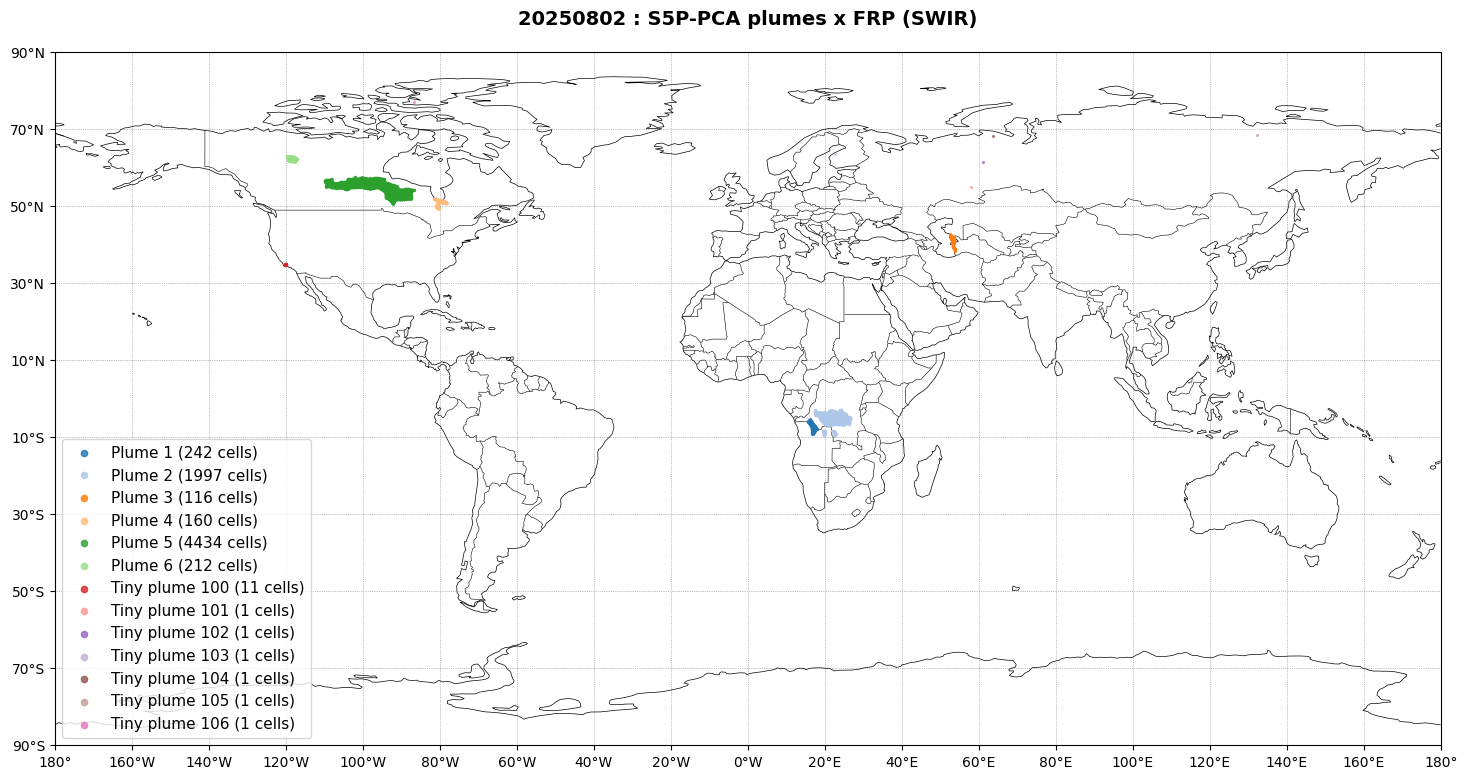

In [8]:
# Toggle save_to to write to disk, or leave None for inline display only
P.plot_plumes_frp(ds_area, ds_post, date_str, frp_channel="SWIR",
                  save_to=output_dir / f"plumes_frp_SWIR_{date_str}.png")


## Map 2 — Fire score per plume

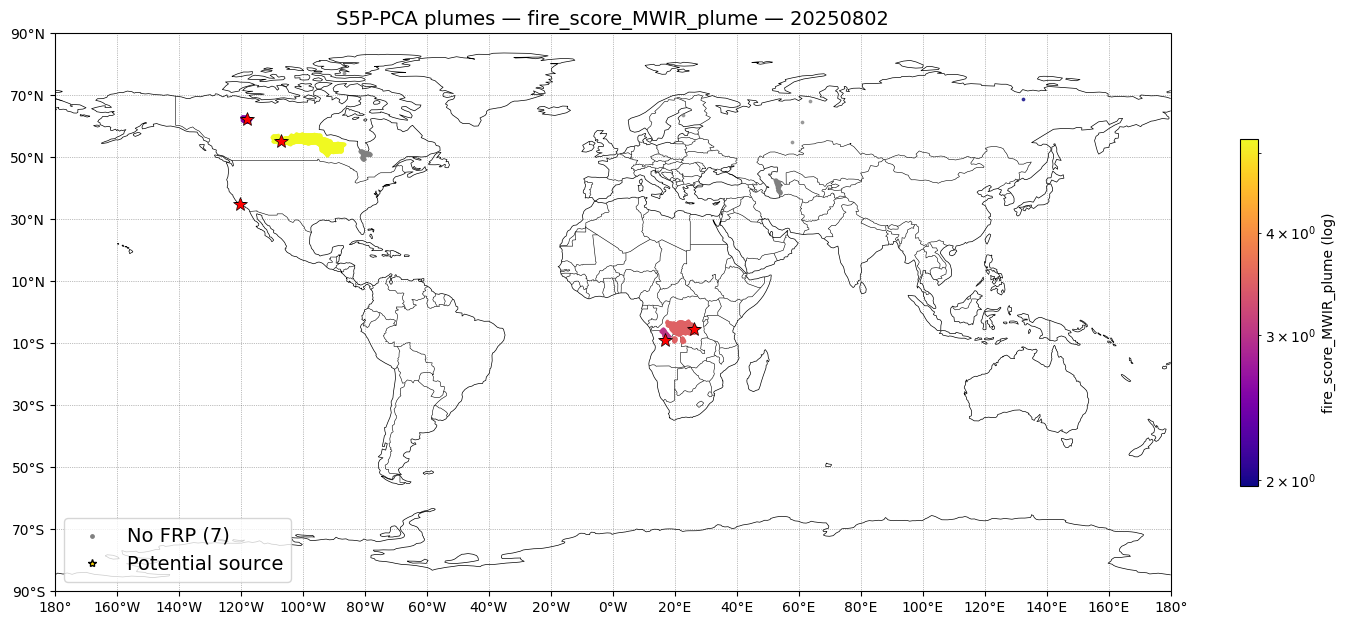

In [9]:
P.plot_fire_score_plume(ds_area, ds_post, df_plumes, date_str, band="MWIR",
                        save_to=output_dir / f"fire_score_plume_MWIR_{date_str}.png")


## Map 3 — Fire score per pixel

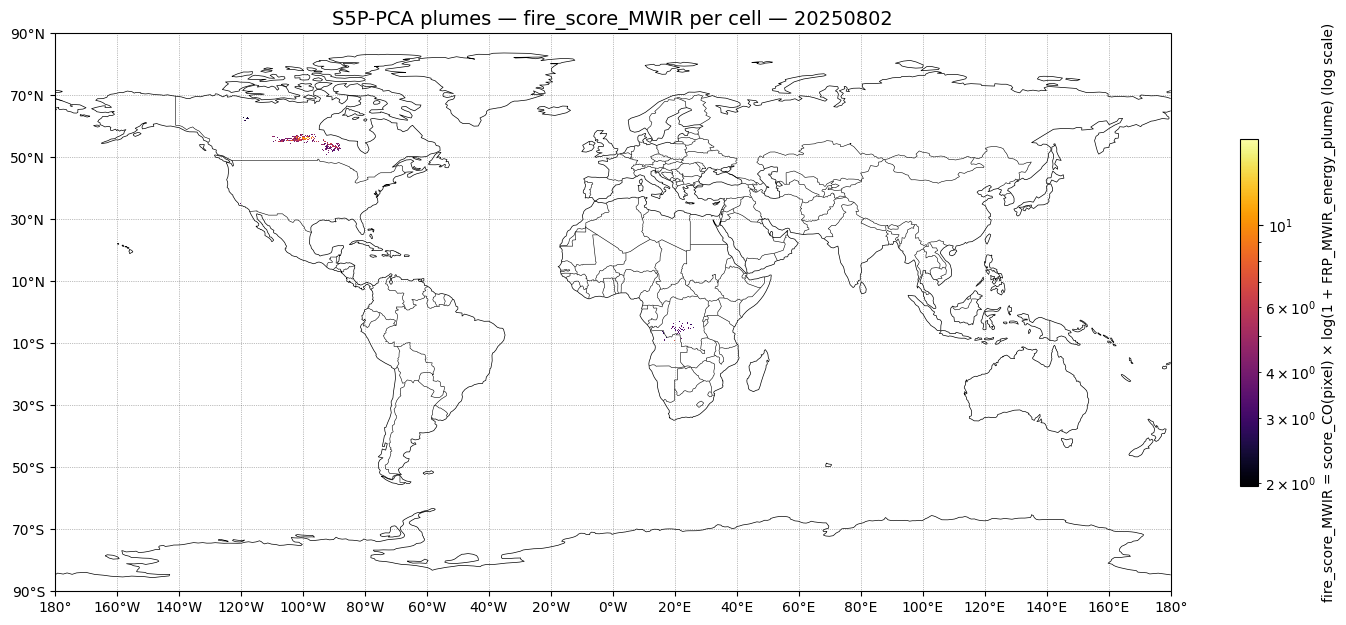

In [10]:
P.plot_fire_score_pixel(ds_area, ds_post, date_str, band="MWIR",
                        save_to=output_dir / f"fire_score_pixel_SWIR_{date_str}.png")
    

## Map 4 — Plume envelopes + source confidence

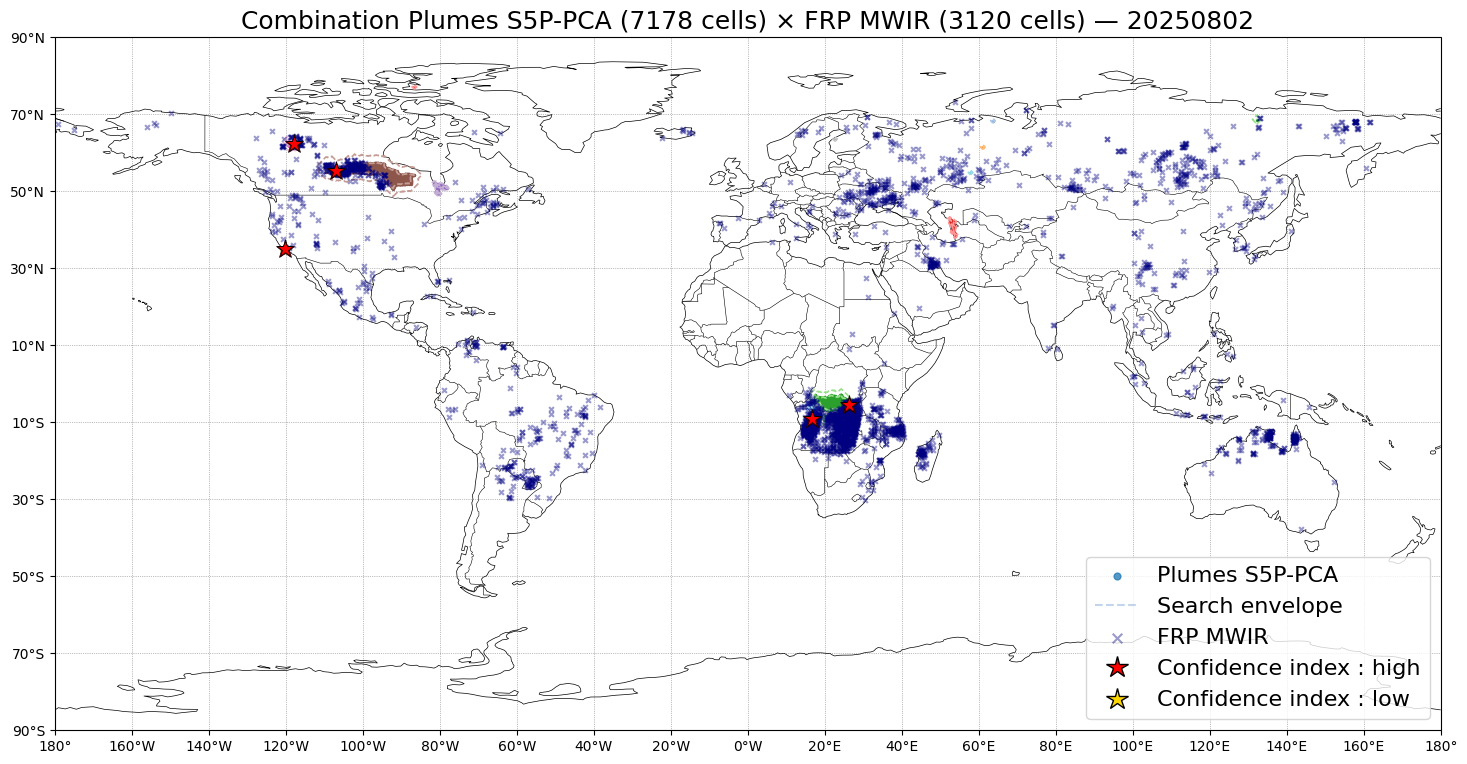

In [11]:
P.plot_plume_envelopes(ds_area, ds_post, df_plumes, date_str, frp_channel="MWIR",
                       save_to=output_dir / f"plume_envelopes_MWIR_{date_str}.png")


## Animations over the last n days (default: n = 5)

In [12]:
# Import all usefulls functions to create the dataset over the n+1 days

"""
S3 Zarr access variant
"""
from datetime import datetime, date
import s3fs
import xarray as xr

from wekeo_combined_chain.utils import select_area


def _make_fs(endpoint_url: str) -> s3fs.S3FileSystem:
    return s3fs.S3FileSystem(
        anon=False,
        client_kwargs={"endpoint_url": endpoint_url},
        config_kwargs={"max_pool_connections": 20},
        s3_additional_kwargs={"retries": {"max_attempts": 5, "mode": "adaptive"}},
    )

def _open_combined_zarr() -> xr.Dataset:
    """
    Open the yearly concatenated global COMBINED Zarr store on S3.
    Time is unordered, so callers must sort/selection by time explicitly.
    """
    BUCKET = "S5P_PCA_V0.1"
    ZARR_PATH = f"s3://{BUCKET}/COMBINED/v1.0/COMBINED_dataset_v0.1.zarr"
    fs = _make_fs("https://s3.waw4-1.cloudferro.com")
    store = fs.get_mapper(ZARR_PATH)
    # consolidated=True for fast metadata read; chunks stay lazy on S3
    return xr.open_zarr(store, consolidated=True)


def remove_vars(ds: xr.Dataset, vars_to_not_remove: list[str]) -> xr.Dataset:
    # general rules of vars to remove:
    remove = []
    vars = ds.data_vars.keys()

    #patterns = ["__night", "_std", "_max", "_min", "_count"]
    #22/06/2026 SP
    patterns = ["__night", "_std", "_max", "_min"]
    
    for var in vars:
        if any([pattern in var for pattern in patterns]) and var not in vars_to_not_remove:
            remove.append(var)

    ds = ds.drop_vars(remove)
    return ds


def get_combined_ds_range(
    area: list[float] = [90., -90., 180., -180.],
    start_day: date = date(2025, 1, 1),
    end_day: date = date(2025, 12, 31),
) -> xr.Dataset:
    """
    Load a date range from the S3 Zarr store and select the requested area.

    The Zarr store is a yearly concatenated global file with unordered time,
    so we sort by time before selecting the [start_day, end_day] slice.
    Area selection is applied lazily on the resulting slice.
    """
    ds = _open_combined_zarr()

    # The store time is unordered: sort once so .sel(time=slice(...)) is reliable.
    ds = ds.sortby("time")

    # Build a [start, end] inclusive slice at day granularity.
    start = datetime(start_day.year, start_day.month, start_day.day)
    end = datetime(end_day.year, end_day.month, end_day.day)
    ds = ds.sel(time=slice(start, end))

    ds = remove_vars(ds, vars_to_not_remove=[])
    ds = select_area(ds, area)

    return ds


In [13]:
# dataset over the n+1 days
from wekeo_combined_chain.animation.plot import animate_cartes_journalieres
from datetime import  timedelta

n = 5 # number of days analysed
band = 'MWIR'
lst_dates = [day - timedelta(days=i) for i in range(1, n+1)][::-1] # dates list
start = lst_dates[0]
end = day

ds_previousdays = get_combined_ds_range(area,start,end)


### Animation 1: S5P-PCA mean score CO

6 frames | 2025-07-28 → 2025-08-02


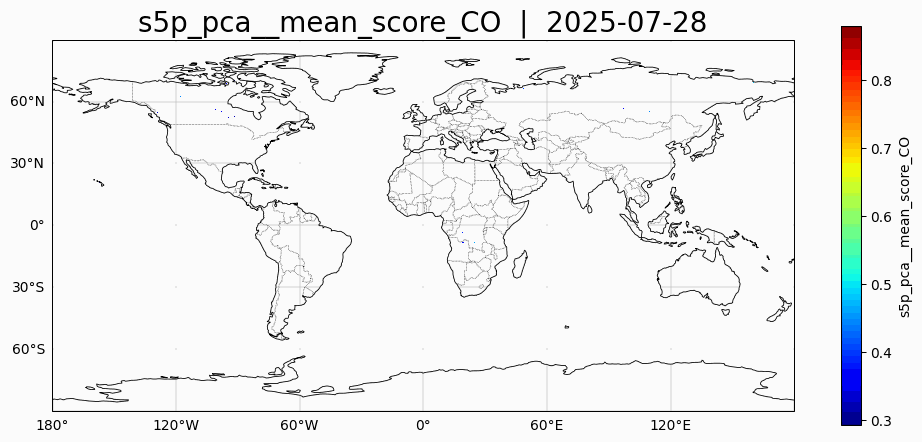

In [14]:
# mean score CO
animate_cartes_journalieres(ds_previousdays,
    varname='s5p_pca__mean_score_CO',
    date_debut=str(start),
    date_fin=str(end),
    duration_ms=400)

### Animation 2: S5P-PCA Plume presence

In [15]:
"""
Coarsen dataset to reduce spatial resolution by block-averaging.
"""

FACTOR = 4 # 12-16 good on a global scale, for regionnal smaller factor advised, around 4-8
dsc = ds_previousdays.coarsen(latitude=FACTOR, longitude=FACTOR, boundary="trim").mean()

from wekeo_combined_chain.timeseries.plot_maps import animate_plume_map

# Interactive slider — scrub through days
animate_plume_map(dsc)

Pre-rendering 6 frames… done.
